# Heart Disease Prediction System

> **LIVE DEPLOYMENT LINK:** `<paste your live Streamlit / PythonAnywhere URL here>`
> *(Required by the assignment: this link must stay at the very top of the notebook.)*

*Adapted from the "Titanic Passenger Survival Prediction System" notebook by Mohsin Afzal and Dr. Rao Muhammad Adeel Nawab. The same 9-step flow is kept, with two deliberate changes: **no Label Encoding** (all inputs are already numeric) and a **real Pre-processing step** .*

## Setup: Running This Notebook From Scratch

Run these in a terminal inside the project folder (same procedure as the Titanic notebook).

1. `python --version`  (Python 3.9 - 3.12 recommended)
2. Create venv: `python -m venv venv`  (macOS/Linux: `python3 -m venv venv`)
3. Activate: `venv\Scripts\activate.bat` (Windows CMD), `venv\Scripts\Activate.ps1` (PowerShell), `source venv/bin/activate` (macOS/Linux)
4. Install packages: `pip install -r requirements-notebook.txt` (the smaller `requirements.txt` is only for the deployed web app)
5. Register kernel: `python -m ipykernel install --user --name=heart-venv --display-name "Python (heart-venv)"`
6. Launch: `jupyter notebook`, choose **Kernel -> Change Kernel -> Python (heart-venv)**, then **Kernel -> Restart & Run All**.
7. When done: `deactivate`

**Files needed in the same folder:** `processed.cleveland.data` (raw UCI file).

## SU Meta Description
<p>
Heart Disease Prediction System: a machine learning model that uses four patient measurements to predict whether heart disease is present, built on the UCI Cleveland dataset.
</p>

## Introduction

##### **Definition** A binary classification ML task that predicts whether a patient has heart disease (1) or not (0) from four clinical attributes (age, chest pain type, maximum heart rate, ST depression).
##### **Application** Educational demonstration of an end-to-end ML system on structured medical data. **It is not a medical device and must not be used for real diagnosis.**

## Input and Output

### Inputs (Features / Attributes) - only 4 selected, as required by the assignment

| **Input Feature** | **Meaning** | **Values (as stored in the dataset)** |
| --- | --- | --- |
| **age** | Age in years | 29 - 77 |
| **cp** | Chest pain type | 1 = typical angina, 2 = atypical angina, 3 = non-anginal pain, 4 = asymptomatic |
| **thalach** | Maximum heart rate achieved (bpm) | 71 - 202 |
| **oldpeak** | ST depression induced by exercise relative to rest | 0.0 - 6.2 |

### Output (Prediction)

| **Output Attribute** | **Possible Values** |
| --- | --- |
| **target** | 0 = No heart disease, 1 = Heart disease present |

*The original UCI column `num` has values 0-4 (0 = no disease, 1-4 = increasing severity). Following common practice, values 1-4 are merged into 1 to get a binary task.*

### Why these 4 attributes?
- All four are **already numeric** in the dataset, so no Label Encoding is required.
- None of them has missing values (the 6 missing values in the Cleveland file are in `ca` and `thal`, which are not used).
- In a quick 5-fold cross-validation comparison of several 4-attribute combinations, this one scored best among the all-numeric options tried (about 0.77 accuracy), clearly ahead of the {age, resting BP, cholesterol, max heart rate} set (about 0.64).
- Note: `cp` is really a category, but its codes are used as-is. This is a simplification (the model treats 1-4 as ordered numbers) and is listed in the Feedback Phase as an improvement.

## Developer & System Information

| | |
| --- | --- |
| **Developer Name** | `<your name and registration number>` |
| **Course** | AIC354 Machine Learning Fundamentals, COMSATS University Islamabad, Lahore Campus |
| **Program Name** | heart_disease_project |
| **IDE** | Jupyter Notebook |
| **Programming Language** | Python 3.x |
| **Libraries** | NumPy, Pandas, Pickle (built-in), scikit-learn, PrettyTable, Matplotlib, Seaborn |
| **Dataset** | UCI Heart Disease (Cleveland subset), https://archive.ics.uci.edu/dataset/45/heart+disease |
| **Date of Completion** | `<date>` |

## Table of Content
- Step 1: Import Libraries
- Step 2: Load Sample Data
- Step 3: Understand and Pre-process Sample Data
- Step 4: Feature Extraction
- Step 5: Label Encoding (**Not required** - all inputs and the output are already numeric)
- Step 6: Execute the Training Phase
- Step 7: Execute the Testing Phase
- Step 8: Execute the Application Phase
- Step 9: Execute the Feedback Phase
- Step 10: Deploy Your Model as a Public Web App

## Code - Heart Disease Prediction

### Step 1: Import Libraries

In [39]:
"""
Purpose of this code:
----------------------
Imports the libraries for data handling, splitting, scaling, training an SVM,
evaluating it, and showing results. Note: LabelEncoder is NOT imported because
this project does not need label encoding.
"""
import numpy as np
import pandas as pd
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler       # feature scaling (not label encoding)
from sklearn.pipeline import make_pipeline
from sklearn import svm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from prettytable import PrettyTable

import matplotlib.pyplot as plt
import seaborn as sns

### Step 2: Load Sample Data

In [40]:
"""
Purpose of this section:
-------------------------
The raw UCI file 'processed.cleveland.data' has NO header row and uses '?' for
missing values. We supply the 14 official column names and tell pandas that
'?' means missing. Then we keep only the 4 chosen inputs plus the output and
save them as 'sample-data.csv' (the "sample data" used by all later steps).
"""
all_columns = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
               "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"]

raw_data = pd.read_csv("processed.cleveland.data", header=None,
                       names=all_columns, na_values="?")

print("Raw data shape (rows, columns):", raw_data.shape)
print("\nMissing values per column in the raw file:")
print(raw_data.isna().sum()[lambda s: s > 0])

# Keep only the 4 selected input attributes + the output
selected_inputs = ["age", "cp", "thalach", "oldpeak"]
sample_data = raw_data[selected_inputs + ["num"]].copy()

# Convert the 5-level 'num' (0-4) into a binary target: 0 = no disease, 1 = disease
sample_data["target"] = (sample_data["num"] > 0).astype(int)
sample_data = sample_data.drop(columns=["num"])
sample_data["cp"] = sample_data["cp"].astype(int)

sample_data.to_csv("sample-data.csv", index=False, header=True)

print("\n\nSample Data:")
print("============\n")
pd.set_option("display.max_rows", 20, "display.max_columns", None)
print(sample_data)

Raw data shape (rows, columns): (303, 14)

Missing values per column in the raw file:
ca      4
thal    2
dtype: int64


Sample Data:

      age  cp  thalach  oldpeak  target
0    63.0   1    150.0      2.3       0
1    67.0   4    108.0      1.5       1
2    67.0   4    129.0      2.6       1
3    37.0   3    187.0      3.5       0
4    41.0   2    172.0      1.4       0
..    ...  ..      ...      ...     ...
298  45.0   1    132.0      1.2       1
299  68.0   4    141.0      3.4       1
300  57.0   4    115.0      1.2       1
301  57.0   2    174.0      0.0       1
302  38.0   3    173.0      0.0       0

[303 rows x 5 columns]


### Step 3: Understand and Pre-process Sample Data

#### Step 3.1: Understand Sample Data

In [41]:
print("\n\nAttributes in Sample Data:")
print("==========================\n")
print(sample_data.columns)

print("\n\nNumber of Instances in Sample Data:", sample_data["age"].count())
print("========================================\n")

print("Summary statistics of the inputs:")
print(sample_data.describe().round(2))

print("\n\nClass distribution of the output (target):")
print("==========================================\n")
print(sample_data["target"].value_counts().rename({0: "No disease (0)", 1: "Disease (1)"}))

print("\nMissing values in the selected columns:", int(sample_data.isna().sum().sum()))



Attributes in Sample Data:

Index(['age', 'cp', 'thalach', 'oldpeak', 'target'], dtype='str')


Number of Instances in Sample Data: 303

Summary statistics of the inputs:
          age      cp  thalach  oldpeak  target
count  303.00  303.00   303.00   303.00  303.00
mean    54.44    3.16   149.61     1.04    0.46
std      9.04    0.96    22.88     1.16    0.50
min     29.00    1.00    71.00     0.00    0.00
25%     48.00    3.00   133.50     0.00    0.00
50%     56.00    3.00   153.00     0.80    0.00
75%     61.00    4.00   166.00     1.60    1.00
max     77.00    4.00   202.00     6.20    1.00


Class distribution of the output (target):

target
No disease (0)    164
Disease (1)       139
Name: count, dtype: int64

Missing values in the selected columns: 0


#### Step 3.2: Pre-process Sample Data
The preprocessing was done while loading the data in Step 2:
- the column names were added (raw file has none),
- `'?'` was read as missing, and it was verified above that the 4 selected columns contain **no missing values**, so no rows had to be dropped or imputed,
- the 5-level `num` output was converted into a 2-class `target`.

No further preprocessing is needed. (Scaling of the inputs is done inside the model pipeline in Step 6.3, so that exactly the same scaling is applied during training, testing and in the web app.)

#### Step 4: Feature Extraction
The 4 attributes are the features. They are directly measured values, so no additional feature extraction is performed.

### Step 5: Label Encoding
**Not required.** All 4 inputs (`age`, `cp`, `thalach`, `oldpeak`) and the output (`target`) are already numeric, so the sample data is used directly as the "encoded" data. This is why this notebook has no `LabelEncoder` objects.

### Step 6: Execute the Training Phase

#### Step 6.1: Splitting Sample Data into Training Data and Testing Data

In [42]:
"""
80% training / 20% testing. Unlike the Titanic notebook (shuffle=False), this
uses a shuffled, STRATIFIED split so both sets keep the same share of
disease / no-disease cases. random_state=0 makes the split reproducible.
"""
training_data, testing_data = train_test_split(
    sample_data,
    test_size=0.2,
    random_state=0,
    shuffle=True,
    stratify=sample_data["target"]
)

training_data.to_csv("training-data.csv", index=False, header=True)
testing_data.to_csv("testing-data.csv", index=False, header=True)

print("Training Data shape:", training_data.shape)
print("Testing Data shape:", testing_data.shape)

Training Data shape: (242, 5)
Testing Data shape: (61, 5)


#### Step 6.2: Splitting Input Vectors and Outputs / Labels of Training Data

In [43]:
input_vector_train = training_data.iloc[:, :-1]
output_label_train = training_data.iloc[:, -1]

print("Input vectors (train) shape:", input_vector_train.shape)
print("Output labels (train) shape:", output_label_train.shape)

Input vectors (train) shape: (242, 4)
Output labels (train) shape: (242,)


#### Step 6.3: Train the Support Vector Classifier

In [44]:
"""
SVC is distance-based, so inputs on very different scales (e.g. thalach ~150
vs oldpeak ~1) would let the large numbers dominate. A StandardScaler is
therefore chained in front of the SVC in a single pipeline. The scaler is
learned from the training data only, and it is saved together with the
classifier, so the web app needs no separate preprocessing code.
"""
print("\n\nTraining the Support Vector Classifier on Training Data")
print("========================================================\n")

svc_model = make_pipeline(StandardScaler(), svm.SVC(gamma="auto", random_state=0))
svc_model.fit(input_vector_train, np.ravel(output_label_train))

print(svc_model)



Training the Support Vector Classifier on Training Data

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(gamma='auto', random_state=0))])


#### Step 6.4: Save the Trained Model

In [45]:
pickle.dump(svc_model, open("svc_trained_model.pkl", "wb"))
print("Saved: svc_trained_model.pkl")

Saved: svc_trained_model.pkl


### Step 7: Execute the Testing Phase

#### Step 7.1: Splitting Input Vectors and Outputs/Labels of Testing Data

In [46]:
input_vector_test = testing_data.iloc[:, :-1]
output_label_test = testing_data.iloc[:, -1]

print("Input vectors (test) shape:", input_vector_test.shape)
print("Output labels (test) shape:", output_label_test.shape)

Input vectors (test) shape: (61, 4)
Output labels (test) shape: (61,)


#### Step 7.2: Load the Saved Model

In [47]:
model = pickle.load(open("svc_trained_model.pkl", "rb"))
print("Model loaded from svc_trained_model.pkl")

Model loaded from svc_trained_model.pkl


#### Step 7.3: Evaluate the Machine Learning Model
##### Step 7.3.1: Make Predictions with the Trained Model on Testing Data

In [48]:
model_predictions = model.predict(input_vector_test)

testing_results = testing_data.copy()
testing_results["Predictions"] = model_predictions
testing_results.to_csv("model-predictions.csv", index=False, header=True)

print("\n\nPredictions Returned by svc_trained_model:")
print("==========================================\n")
print(testing_results)



Predictions Returned by svc_trained_model:

      age  cp  thalach  oldpeak  target  Predictions
125  45.0   2    175.0      0.6       0            0
83   68.0   3    150.0      1.6       1            0
53   44.0   2    188.0      0.0       0            0
45   58.0   3    165.0      2.5       1            1
248  52.0   4    168.0      1.0       1            0
..    ...  ..      ...      ...     ...          ...
132  29.0   2    202.0      0.0       0            0
15   57.0   3    174.0      1.6       0            0
96   59.0   4    142.0      1.2       1            1
208  55.0   2    155.0      0.0       0            0
2    67.0   4    129.0      2.6       1            1

[61 rows x 6 columns]


#### Step 7.4: Calculate the Accuracy Score

In [49]:
model_accuracy_score = accuracy_score(testing_results["target"], testing_results["Predictions"])

print("\n\nAccuracy Score:")
print("===============\n")
print(round(model_accuracy_score, 2))



Accuracy Score:

0.74


#### Step 7.5: Detailed Evaluation Metrics (Precision, Recall, F1, Confusion Matrix)


Classification Report:

                precision    recall  f1-score   support

No Disease (0)       0.70      0.91      0.79        33
   Disease (1)       0.83      0.54      0.65        28

      accuracy                           0.74        61
     macro avg       0.77      0.72      0.72        61
  weighted avg       0.76      0.74      0.73        61


Confusion Matrix:

                    Predicted: No Disease  Predicted: Disease
Actual: No Disease                     30                   3
Actual: Disease                        13                  15


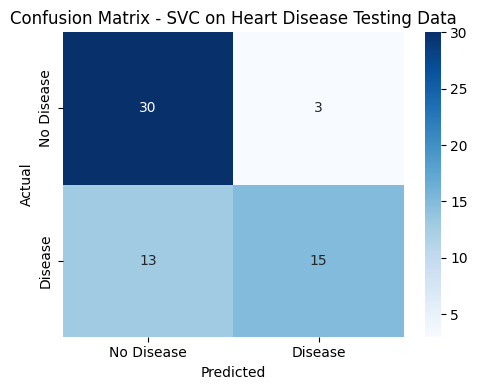

In [50]:
"""
For a medical task, accuracy alone is not enough:
- Recall (class 1) = of the patients who really have heart disease, how many did we catch?
  Missing a sick patient (false negative) is the costly mistake here.
- Precision (class 1) = of the patients flagged as sick, how many really are?
"""
print("\nClassification Report:")
print("=======================\n")
print(classification_report(
    testing_results["target"], testing_results["Predictions"],
    target_names=["No Disease (0)", "Disease (1)"]
))

conf_matrix = confusion_matrix(testing_results["target"], testing_results["Predictions"])
conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=["Actual: No Disease", "Actual: Disease"],
    columns=["Predicted: No Disease", "Predicted: Disease"]
)
print("\nConfusion Matrix:")
print("==================\n")
print(conf_matrix_df)

plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVC on Heart Disease Testing Data")
plt.tight_layout()
plt.show()

### Step 8: Execute the Application Phase

#### Step 8.1: Take Input from User

In [51]:
"""
A demo patient is pre-filled so the notebook runs top-to-bottom without typing.
To enter your own values interactively, replace the four lines below with:
    age_input     = float(input("Age in years (29-77): "))
    cp_input      = int(input("Chest pain type (1=typical, 2=atypical, 3=non-anginal, 4=asymptomatic): "))
    thalach_input = float(input("Maximum heart rate achieved (71-202): "))
    oldpeak_input = float(input("ST depression (0.0-6.2): "))
"""
age_input = 58
cp_input = 4
thalach_input = 112
oldpeak_input = 2.0

print(f"age: {age_input}, cp: {cp_input}, thalach: {thalach_input}, oldpeak: {oldpeak_input}")

age: 58, cp: 4, thalach: 112, oldpeak: 2.0


#### Step 8.2: Convert User Input into Feature Vector (Exactly Same as Feature Vectors of Sample Data)

In [52]:
user_input = pd.DataFrame({
    "age": [age_input],
    "cp": [cp_input],
    "thalach": [thalach_input],
    "oldpeak": [oldpeak_input]
})

print("\n\nUser Input Feature Vector:")
print("==========================\n")
print(user_input)



User Input Feature Vector:

   age  cp  thalach  oldpeak
0   58   4      112      2.0


#### Step 8.3: Label Encoding of Feature Vector
**Not required** - the user's values are already numeric, and the scaling is applied automatically by the saved pipeline.

In [53]:
unseen_data_features = user_input.copy()   # same column order as the training inputs
print(unseen_data_features)

   age  cp  thalach  oldpeak
0   58   4      112      2.0


#### Step 8.4: Load the Saved Model

In [54]:
model = pickle.load(open("svc_trained_model.pkl", "rb"))

#### Step 8.5: Model Prediction
##### Step 8.5.1: Apply Model on the Feature Vector of the unseen instance and return Prediction to the User

In [55]:
predicted_class = model.predict(unseen_data_features)[0]

if predicted_class == 1:
    prediction = "HEART DISEASE PRESENT"
else:
    prediction = "NO HEART DISEASE"

# Clean Pandas summary table
df_summary = pd.DataFrame([{"Prediction": prediction}])
display(df_summary)

print("\n(Educational demo only - not a medical diagnosis.)")

,Prediction
0,HEART DISEASE PRESENT



(Educational demo only - not a medical diagnosis.)


### Step 9: Execute the Feedback Phase

#### Step 9.1: Collect Feedback from Users and Domain Experts on Performance of the Model Deployed in the Real World

In [56]:
"""
ILLUSTRATIVE example feedback (no real clinician was consulted). Replace it
with real feedback from your classmates / a domain expert after sharing your
live link.
"""
example_feedback = pd.DataFrame({
    "Reviewer": ["Domain Expert (Cardiology) - example", "Student Tester - example", "Student Tester - example"],
    "Case": [
        "Older patient, asymptomatic chest pain, low max heart rate, high ST depression",
        "Young patient, typical angina, high max heart rate, no ST depression",
        "Patients who actually have heart disease but were predicted healthy",
    ],
    "Feedback": [
        "Plausible: these are recognised risk indicators, so a 'disease' prediction makes sense.",
        "Plausible: the combination looks low-risk.",
        "Most serious problem: the model misses a large share of sick patients (low recall on class 1). Unacceptable for screening.",
    ],
})
print(example_feedback.to_string(index=False))

                            Reviewer                                                                           Case                                                                                                                   Feedback
Domain Expert (Cardiology) - example Older patient, asymptomatic chest pain, low max heart rate, high ST depression                                    Plausible: these are recognised risk indicators, so a 'disease' prediction makes sense.
            Student Tester - example           Young patient, typical angina, high max heart rate, no ST depression                                                                                 Plausible: the combination looks low-risk.
            Student Tester - example            Patients who actually have heart disease but were predicted healthy Most serious problem: the model misses a large share of sick patients (low recall on class 1). Unacceptable for screening.


#### Step 9.2: Make a List of Potential Improvements

In [57]:
improvements = [
    "Improve recall for the 'disease' class (the model misses too many sick patients), e.g. by class_weight='balanced' or by tuning the decision threshold",
    "Treat chest-pain type (cp) as a true category (e.g. one-hot encoding) instead of ordered numbers",
    "Use more informative attributes (e.g. thal, ca, exang) or all 13 attributes, which usually gives higher accuracy",
    "Use cross-validation instead of one 80/20 split: with only 303 patients, a single test set of 61 is a noisy estimate",
    "Compare other models (Logistic Regression, Random Forest) and tune C and gamma of the SVC",
]
for i, item in enumerate(improvements, 1):
    print(f"{i}. {item}")

1. Improve recall for the 'disease' class (the model misses too many sick patients), e.g. by class_weight='balanced' or by tuning the decision threshold
2. Treat chest-pain type (cp) as a true category (e.g. one-hot encoding) instead of ordered numbers
3. Use more informative attributes (e.g. thal, ca, exang) or all 13 attributes, which usually gives higher accuracy
4. Use cross-validation instead of one 80/20 split: with only 303 patients, a single test set of 61 is a noisy estimate
5. Compare other models (Logistic Regression, Random Forest) and tune C and gamma of the SVC


#### Step 9.3: Improve the Model Based on Feedback

In [58]:
print("Next version: retrain with class_weight='balanced' and more attributes, re-run Steps 6-7, "
      "and replace svc_trained_model.pkl only if recall on the disease class improves without a large drop in precision.")

Next version: retrain with class_weight='balanced' and more attributes, re-run Steps 6-7, and replace svc_trained_model.pkl only if recall on the disease class improves without a large drop in precision.


## Step 10: Deploy Your Model as a Public Web App

The notebook only works on your own computer. Deploying turns the saved model into a web page anyone can use. Streamlit Community Cloud (free) is used here; the assignment also allows PythonAnywhere.

#### Step 10.1: Files to Upload
Put these in one GitHub repository (this notebook created most of them):

| File | Purpose |
| --- | --- |
| `app.py` | The Streamlit web app (provided alongside this notebook) |
| `svc_trained_model.pkl` | The trained pipeline saved in Step 6.4 |
| `requirements.txt` | Packages the app needs |
| `processed.cleveland.data`, `sample-data.csv`, this `.ipynb` | Dataset and code (also needed for the Google Classroom submission) |

**Important:** re-run this notebook on your own machine and upload the `svc_trained_model.pkl` it creates. A pickle must be loaded with (nearly) the same scikit-learn version it was saved with.

#### Step 10.2: Create a GitHub Account and Repository
1. Sign up at https://github.com, then **+ -> New repository** (name it e.g. `heart-disease-app`, set it **Public**).
2. **Add file -> Upload files**, drag in the files from the table above, then **Commit**.

#### Step 10.3: The Web App
`app.py` loads the pickled pipeline, collects the four inputs with Streamlit widgets and calls `model.predict(...)` on a button click. Because there is no label encoding and the scaler lives inside the pipeline, the app is short and has no encoder to keep in sync.

#### Step 10.4 - 10.5: Create a Streamlit Account and Deploy
1. Go to https://share.streamlit.io and **Sign in with GitHub**.
2. **Create app -> Deploy a public app from GitHub**; choose your repository, branch `main`, main file path `app.py`.
3. Click **Deploy** and wait a few minutes. You get a URL like `https://<something>.streamlit.app`.

#### Step 10.6: Troubleshooting
- **`ModuleNotFoundError`:** in the app's **Settings -> General**, select Python 3.11 or 3.12 and reboot.
- **Stuck on "in the oven":** open **Manage app**, read the build log for red errors, fix `requirements.txt`, reboot.
- **`requirements.txt` ignored:** it must be in the same folder as `app.py`.
- **Model loading error / version warning:** retrain locally and re-upload the `.pkl`.

#### Step 10.7: Share Your Live Link
Paste the URL at the **top of this notebook** (assignment requirement) and in your repository's README.

---

## Conclusion
The model uses only four numeric attributes (age, chest pain type, maximum heart rate, ST depression) from the UCI Cleveland data (303 patients) and needs no label encoding. The Support Vector Classifier (with feature scaling) reached an accuracy of 0.74 on the 61-patient test set (5-fold cross-validation during attribute selection gave roughly 0.77). Precision for the disease class is good (0.83), but **recall is only 0.54: 13 of the 28 patients who truly had heart disease were predicted healthy.** For a medical screening task this is the main weakness, and it is the first item in the improvement list (Step 9.2). Because the test set is small, these numbers are only a rough estimate. The model is a learning exercise and must not be used for real diagnosis.